Accuracy test: 0.8


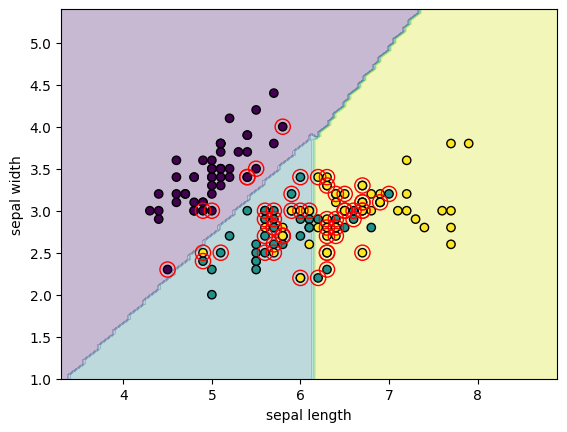

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Datos: Iris, 2 features (longitud y anchura del sépalo)
X, y = datasets.load_iris(return_X_y=True)
X = X[:, :2]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

# 2. Modelo
clf = SVC(kernel="linear", C=1.0)   # probar también kernel="rbf", gamma="scale"
clf.fit(X_tr, y_tr)
print("Accuracy test:", clf.score(X_te, y_te))

# 3. Frontera de decisión + vectores soporte
DecisionBoundaryDisplay.from_estimator(clf, X, response_method="predict", alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
plt.scatter(*clf.support_vectors_.T, s=120, facecolors="none", edgecolors="r")
plt.xlabel("sepal length"); plt.ylabel("sepal width")
plt.show()

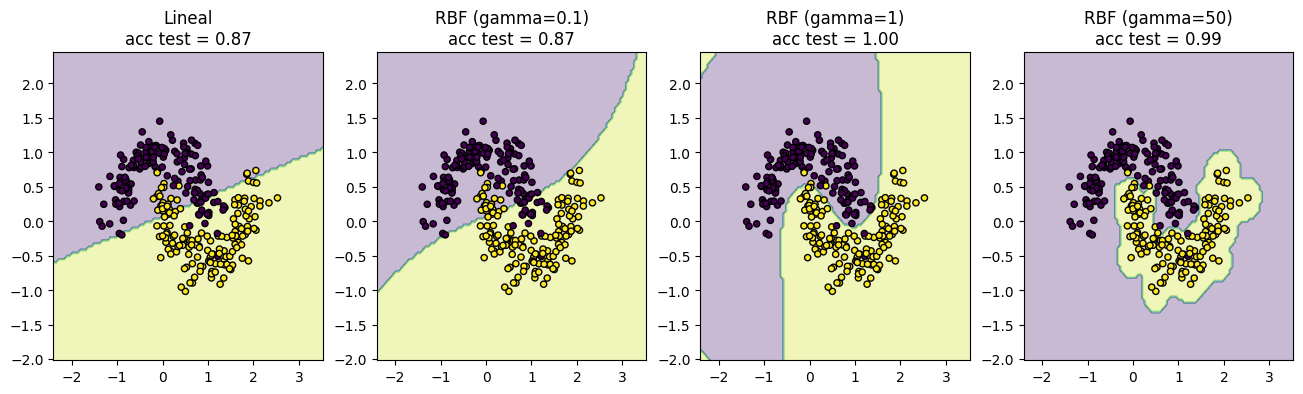

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay

X, y = make_moons(n_samples=300, noise=0.2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

modelos = {
    "Lineal":            SVC(kernel="linear", C=1),
    "RBF (gamma=0.1)":   SVC(kernel="rbf", C=1, gamma=0.1),
    "RBF (gamma=1)":     SVC(kernel="rbf", C=1, gamma=1),
    "RBF (gamma=50)":    SVC(kernel="rbf", C=1, gamma=50),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (nombre, clf) in zip(axes, modelos.items()):
    clf.fit(X_tr, y_tr)
    DecisionBoundaryDisplay.from_estimator(clf, X, response_method="predict", alpha=0.3, ax=ax)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=20)
    ax.set_title(f"{nombre}\nacc test = {clf.score(X_te, y_te):.2f}")
plt.show()

In [3]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(SVC(kernel="rbf"),
                    {"C": [0.1, 1, 10, 100], "gamma": [0.01, 0.1, 1, 10]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.score(X_te, y_te))

{'C': 10, 'gamma': 10} 0.9888888888888889
